In [1]:
import os
import sys
import pickle
import gzip
import numpy as np
import tensorflow as tf
import multiprocessing
from matplotlib import rcParams

# ── Path setup ────────────────────────────────────────────────────────────
GLM_DIR = '/Users/akhilbandi/Library/Mobile Documents/com~apple~CloudDocs/Documents/Portfolio/code_projects/Context Paper Code/GLM_encoding_model'
if GLM_DIR not in sys.path:
    sys.path.insert(0, GLM_DIR)

# ── Pipeline imports ───────────────────────────────────────────────────────
from session_pipeline import (
    extract_data,
    generate_predictors,
    stack_design_matrices,
    save_glm_data,
    open_glm_stacked_data,
    prepare_features_for_glm,
    fit_glm_single_session,
    run_lesion_models,
)

# ── Plot style ─────────────────────────────────────────────────────────────
rcParams['font.family'] = 'Arial'
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False

print("✓ Imports complete")

✓ Imports complete


In [2]:
import importlib
import session_pipeline
importlib.reload(session_pipeline)   # force fresh read from disk

sp = session_pipeline

lam = 10.0 ** np.linspace(-1, -6, 5)   # mirror what's in fit_glm_single_session

print("─── session_pipeline constants ─────────────────────")
print(f"  Y_SCALE          = {sp.Y_SCALE}")
print(f"  Y_SMOOTH_SIGMA   = {sp.Y_SMOOTH_SIGMA} frames")
print(f"  MODEL_1_DIR      = {sp.MODEL_1_DIR}")

print("\n─── GLM_CV hyperparameters ──────────────────────────")
print(f"  lambda_series    = {lam}")
print(f"  l1_ratio         = 0.95")
print(f"  smooth_strength  = 0.1")
print(f"  learning_rate    = 1e-3")
print(f"  max_iter_per_λ   = 5000")
print(f"  convergence_tol  = 1e-5")

─── session_pipeline constants ─────────────────────
  Y_SCALE          = 10
  Y_SMOOTH_SIGMA   = 5 frames
  MODEL_1_DIR      = Model_1_results

─── GLM_CV hyperparameters ──────────────────────────
  lambda_series    = [1.00000000e-01 5.62341325e-03 3.16227766e-04 1.77827941e-05
 1.00000000e-06]
  l1_ratio         = 0.95
  smooth_strength  = 0.1
  learning_rate    = 1e-3
  max_iter_per_λ   = 5000
  convergence_tol  = 1e-5


In [3]:
print("System Resources:")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")

# Check for Metal GPU on Mac
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"\n✓ GPU Available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  - {gpu}")
    
    # Enable memory growth
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("  ✓ Memory growth enabled")
    except:
        pass
else:
    print("\n⚠️  No GPU detected")

# CPU info
n_cores = multiprocessing.cpu_count()
print(f"\nCPU cores: {n_cores}")
print("="*60)

System Resources:
TensorFlow version: 2.16.2

✓ GPU Available: 1 device(s)
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  ✓ Memory growth enabled

CPU cores: 24


In [4]:
# ── Session registry ──────────────────────────────────────────────────────
# Keys: mouse_ID  |  Values: list of recording dates

PPC_AVC = {
    'IS-2-1L': ['2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
                '2025-03-20', '2025-03-26', '2025-04-02', '2025-04-04', 
                '2025-04-08', '2025-04-09', '2025-05-05', '2025-05-27', 
                '2025-05-28', '2025-05-30', '2025-11-20'],
    'IS-3-1R': ['2024-12-23', '2024-12-24', '2024-12-27', '2024-12-28'],
    'JP-2-1L': ['2025-08-19', '2025-08-26', '2025-09-16', '2025-09-17',
                '2025-09-19', '2025-09-22'],
    'KA-1-00': ['2025-12-16', '2026-01-08'],
    'KA-2-00': ['2026-01-08', '2026-01-13', '2026-01-14', '2026-01-28'],
    'KO-5-1L': ['2026-03-05', '2026-03-06', '2026-03-12', '2026-03-13'],
    'KO-6-00': ['2026-03-12']
}

# IS-2-1L_bad: '2025-04-14', '2025-04-15', '2025-04-22', '2025-05-06', '2025-05-08'

# PPC_AVC = {
#     'KO-5-1L': ['2026-03-05', '2026-03-06', '2026-03-12', '2026-03-13'],
#     'KO-6-00': ['2026-03-12']
# }

# PPC_AVC = {
#     'IS-2-1L': ['2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13']
# }

total = sum(len(v) for v in PPC_AVC.values())
print(f"Session registry: {len(PPC_AVC)} mice | {total} sessions total")

Session registry: 7 mice | 36 sessions total


In [5]:
import gc
import glob as _glob

BASE_DATA_PATH = '/Volumes/Akhil Data/Akhil/ProcessedData'

# ── IMPORTANT: Pipeline version note ─────────────────────────────────────
# The predictor_builder was updated to restrict position_only bumps to the
# proximal zone (0–350 cm) via pos_only_y_max=350.0.  This changes the
# design matrix X, so any previously saved results are NOT comparable to
# results produced with the current code.
#
# If you have old glm_M1_full.pkl files from before this change,
# re-run with skip_existing=False to regenerate them with the new predictors.
# ─────────────────────────────────────────────────────────────────────────

EXPECTED_LESION_GROUPS = [
    'position_only', 'audio_context', 'audio_stim',
    'visual_context', 'visual_stim', 'velocity',
    'choice_spatial', 'turn_onset', 'outcome',
]

def check_session_results(mouse_ID, date):
    """
    Inspect the Model_1_results folder and return which outputs already exist.

    Returns
    -------
    dict with keys:
        'full_model'    : bool  — glm_M1_full.pkl present
        'lesion_groups' : dict  — {group_name: bool} for each expected group
        'lesion_all'    : bool  — glm_M1_lesion_all.pkl present
        'all_complete'  : bool  — full model + all lesion files present
        'missing_lesion_groups' : list of str  — groups whose pkl is absent
    """
    res_dir = os.path.join(BASE_DATA_PATH, mouse_ID, date, 'Model_1_results')
    full_done = os.path.exists(os.path.join(res_dir, 'glm_M1_full.pkl'))
    all_done  = os.path.exists(os.path.join(res_dir, 'glm_M1_lesion_all.pkl'))
    lesion_done = {
        g: os.path.exists(os.path.join(res_dir, f'glm_M1_lesion_{g}.pkl'))
        for g in EXPECTED_LESION_GROUPS
    }
    missing = [g for g, done in lesion_done.items() if not done]
    return {
        'full_model':            full_done,
        'lesion_groups':         lesion_done,
        'lesion_all':            all_done,
        'all_complete':          full_done and all_done and not missing,
        'missing_lesion_groups': missing,
    }

def run_all_sessions(sessions_dict, skip_existing=True, neural_metric='deconv'):
    """
    Run the full GLM pipeline for every (mouse_ID, date) in sessions_dict.

    Parameters
    ----------
    sessions_dict : dict
        {mouse_ID: [date1, date2, ...]}  — e.g. PPC_AVC or a subset
    skip_existing : bool
        Controls granular resume behaviour (three cases):
          • full model + all lesion files present  → skip session entirely
          • full model done, some lesion pkls missing → skip fitting,
            load saved results, refit only the missing lesion groups
          • full model missing  → run entire pipeline from scratch
        Set to False to force a complete re-run of everything.
    neural_metric : str
        Which neural signal to use ('deconv', 'dff', 'z_dff').

    Returns
    -------
    results_log : list of dict
        One entry per session with keys: mouse_ID, date, status.

    Examples
    --------
    run_all_sessions(PPC_AVC)
    run_all_sessions({'IS-2-1L': ['2025-03-10']})
    run_all_sessions({'KO-5-1L': ['2026-03-05']}, skip_existing=False)
    """
    results_log = []
    total = sum(len(v) for v in sessions_dict.values())
    print(f'Starting pipeline: {len(sessions_dict)} mice | {total} sessions')

    for mouse_ID, dates in sessions_dict.items():
        for date in dates:

            # ── Granular skip / resume logic ───────────────────────────────
            status = check_session_results(mouse_ID, date)

            if skip_existing and status['all_complete']:
                print(f'  [SKIP] {mouse_ID} / {date} — all results exist')
                results_log.append({'mouse_ID': mouse_ID, 'date': date, 'status': 'skipped'})
                continue

            if skip_existing and status['full_model']:
                # Full model done but some lesion pkls are missing — resume lesions only
                missing = status['missing_lesion_groups']
                print(f'\n  [RESUME] {mouse_ID} / {date} — full model done, '
                      f'fitting {len(missing)} missing lesion group(s): {missing}')
                X = Y = metadata = predictor_info = predictor_info_split = all_results = None
                try:
                    full_path = os.path.join(BASE_DATA_PATH, mouse_ID, date,
                                             'Model_1_results', 'glm_M1_full.pkl')
                    with open(full_path, 'rb') as f:
                        all_results = pickle.load(f)

                    X, Y, metadata, _, predictor_info, _ = \
                        open_glm_stacked_data(mouse_ID, date, print_summary=False)
                    predictor_info_split, _ = prepare_features_for_glm(predictor_info)

                    # skip_existing=True → run_lesion_models loads cached groups
                    # and only refits the missing ones
                    run_lesion_models(
                        X, Y, metadata, all_results, predictor_info_split,
                        mouse_ID=mouse_ID, date=date, skip_existing=True,
                    )

                    results_log.append({'mouse_ID': mouse_ID, 'date': date, 'status': 'success'})
                    print(f'\n  ✓ Completed: {mouse_ID} / {date}  [lesion resume]')

                except Exception as e:
                    import traceback
                    print(f'\n  ✗ FAILED (lesion resume): {mouse_ID} / {date}')
                    traceback.print_exc()
                    results_log.append({'mouse_ID': mouse_ID, 'date': date, 'status': f'error: {e}'})

                finally:
                    del X, Y, metadata, predictor_info, predictor_info_split, all_results
                    gc.collect()
                continue
            # ── Full pipeline (full model missing) ─────────────────────────

            print(f'\n{"="*60}')
            print(f'  Running: {mouse_ID} / {date}')
            print(f'{"="*60}')

            # Pre-declare ALL large variables — guarantees finally can always del them
            glm_data_dict = design_matrices = X = Y = metadata = None
            group_indices = predictor_names = predictor_info = None
            predictor_info_split = feature_group_size = model_cv = all_results = None
            lesion_results = None

            try:
                # 1. Load raw trial data
                glm_data_dict = extract_data(mouse_ID, date)

                # 2. Build per-trial design matrices
                design_matrices, predictor_names, predictor_info = generate_predictors(glm_data_dict)

                # 3. Stack X / Y  (needs glm_data_dict for neural traces)
                X, Y, metadata, group_indices = stack_design_matrices(
                    glm_data_dict, design_matrices, predictor_info,
                    neural_metric=neural_metric
                )

                # 4. Save stacked data — free the large raw objects immediately
                save_glm_data(X, Y, design_matrices, predictor_names,
                              predictor_info, metadata, group_indices, mouse_ID, date)
                del glm_data_dict, design_matrices, X, Y
                glm_data_dict = design_matrices = X = Y = None
                gc.collect()

                # 5. Reload from disk (applies Y_SCALE scaling) + split predictor groups
                X, Y, metadata, predictor_names, predictor_info, group_indices = \
                    open_glm_stacked_data(mouse_ID, date, print_summary=False)
                predictor_info_split, feature_group_size = prepare_features_for_glm(predictor_info)

                # 6. Fit full GLM → saves Model_1_results/glm_M1_full.pkl
                model_cv, all_results, _, _ = fit_glm_single_session(
                    X, Y, metadata, feature_group_size, predictor_info_split, mouse_ID, date
                )

                # Free model_cv (stores all fold weights) — all_results has the summary
                del model_cv
                model_cv = None
                gc.collect()

                # 7. Lesion models → saves glm_M1_lesion_{group}.pkl + glm_M1_lesion_all.pkl
                #    skip_existing=True is safe here even on a fresh run (no cached files exist)
                lesion_results = run_lesion_models(
                    X, Y, metadata, all_results, predictor_info_split,
                    mouse_ID=mouse_ID, date=date, skip_existing=True,
                )

                results_log.append({'mouse_ID': mouse_ID, 'date': date, 'status': 'success'})
                print(f'\n  ✓ Completed: {mouse_ID} / {date}')

            except Exception as e:
                import traceback
                print(f'\n  ✗ FAILED: {mouse_ID} / {date}')
                traceback.print_exc()
                results_log.append({'mouse_ID': mouse_ID, 'date': date, 'status': f'error: {e}'})

            finally:
                # Always runs — releases all large objects before moving to the next session
                del glm_data_dict, design_matrices, X, Y, metadata
                del group_indices, predictor_names, predictor_info
                del predictor_info_split, feature_group_size, model_cv, all_results
                del lesion_results
                gc.collect()


    # ── Summary ───────────────────────────────────────────────────────────
    n_ok   = sum(1 for r in results_log if r['status'] == 'success')
    n_skip = sum(1 for r in results_log if r['status'] == 'skipped')
    n_fail = sum(1 for r in results_log if r['status'].startswith('error'))

    print(f'\n{"="*60}')
    print(f'Run complete — {total} sessions:  '
          f'✓ {n_ok} success  |  – {n_skip} skipped  |  ✗ {n_fail} failed')
    print(f'{"="*60}')
    for r in results_log:
        if r['status'] == 'success':
            icon = '✓'
        elif r['status'] == 'skipped':
            icon = '–'
        else:
            icon = '✗'
        print(f'  {icon}  {r["mouse_ID"]} / {r["date"]}  [{r["status"]}]')

    return results_log

print('✓ run_all_sessions defined')

✓ run_all_sessions defined


In [10]:
completed_sessions = {}
for mouse_ID, dates in PPC_AVC.items():
    for date in dates:
        status = check_session_results(mouse_ID, date)
        if status['all_complete']:
            completed_sessions.setdefault(mouse_ID, []).append(date)

print(f"Completed: {sum(len(v) for v in completed_sessions.values())} / "
      f"{sum(len(v) for v in PPC_AVC.values())} sessions")
for mouse, dates in completed_sessions.items():
    print(f"  {mouse}: {dates}")

Completed: 1 / 21 sessions
  IS-3-1R: ['2024-12-23']


In [8]:
PPC_AVC = {
    'IS-3-1R': ['2024-12-23', '2024-12-24', '2024-12-27', '2024-12-28'],
    'JP-2-1L': ['2025-08-19', '2025-08-26', '2025-09-16', '2025-09-17',
                '2025-09-19', '2025-09-22'],
    'KA-1-00': ['2025-12-16', '2026-01-08'],
    'KA-2-00': ['2026-01-08', '2026-01-13', '2026-01-14', '2026-01-28'],
    'KO-5-1L': ['2026-03-05', '2026-03-06', '2026-03-12', '2026-03-13'],
    'KO-6-00': ['2026-03-12']
}

In [9]:
# ── Run pipeline ──────────────────────────────────────────────────────────
# Run all sessions (skips any that already have results saved):
results_log = run_all_sessions(PPC_AVC, skip_existing=True)

# ── Uncomment below to run a specific subset instead ──────────────────────
# results_log = run_all_sessions({'IS-2-1L': ['2025-03-10']})
# results_log = run_all_sessions({'KO-5-1L': ['2026-03-05']}, skip_existing=False)

Starting pipeline: 6 mice | 21 sessions
  [SKIP] IS-3-1R / 2024-12-23 — all results exist

  [RESUME] IS-3-1R / 2024-12-24 — full model done, fitting 9 missing lesion group(s): ['position_only', 'audio_context', 'audio_stim', 'visual_context', 'visual_stim', 'velocity', 'choice_spatial', 'turn_onset', 'outcome']
Loading: /Volumes/Akhil Data/Akhil/ProcessedData/IS-3-1R/2024-12-24/glm_data_stacked.pkl
  ✓ Loaded  X: (46922, 150)  Y: (46922, 2139)  [smoothed σ=5fr + clipped]
Predictor groups:
  position_only       : 10 features  (cols 0–9)
  audio_context       : 10 features  (cols 10–19)
  audio_stim          : 10 features  (cols 20–29)
  visual_context      : 10 features  (cols 30–39)
  visual_stim         : 10 features  (cols 40–49)
  velocity            : 20 features  (cols 50–69)
  choice_spatial      : 60 features  (cols 70–129)
  turn_onset          :  8 features  (cols 130–137)
  outcome             : 12 features  (cols 138–149)

Total: 150 features

Running lesion models: IS-3-1R

KeyboardInterrupt: 

### diagnostics

Loading: /Volumes/Akhil Data/Akhil/ProcessedData/KO-6-00/2026-03-12/glm_data_stacked.pkl
  ✓ Loaded  X: (66552, 150)  Y: (66552, 692)  [smoothed σ=5fr + clipped]


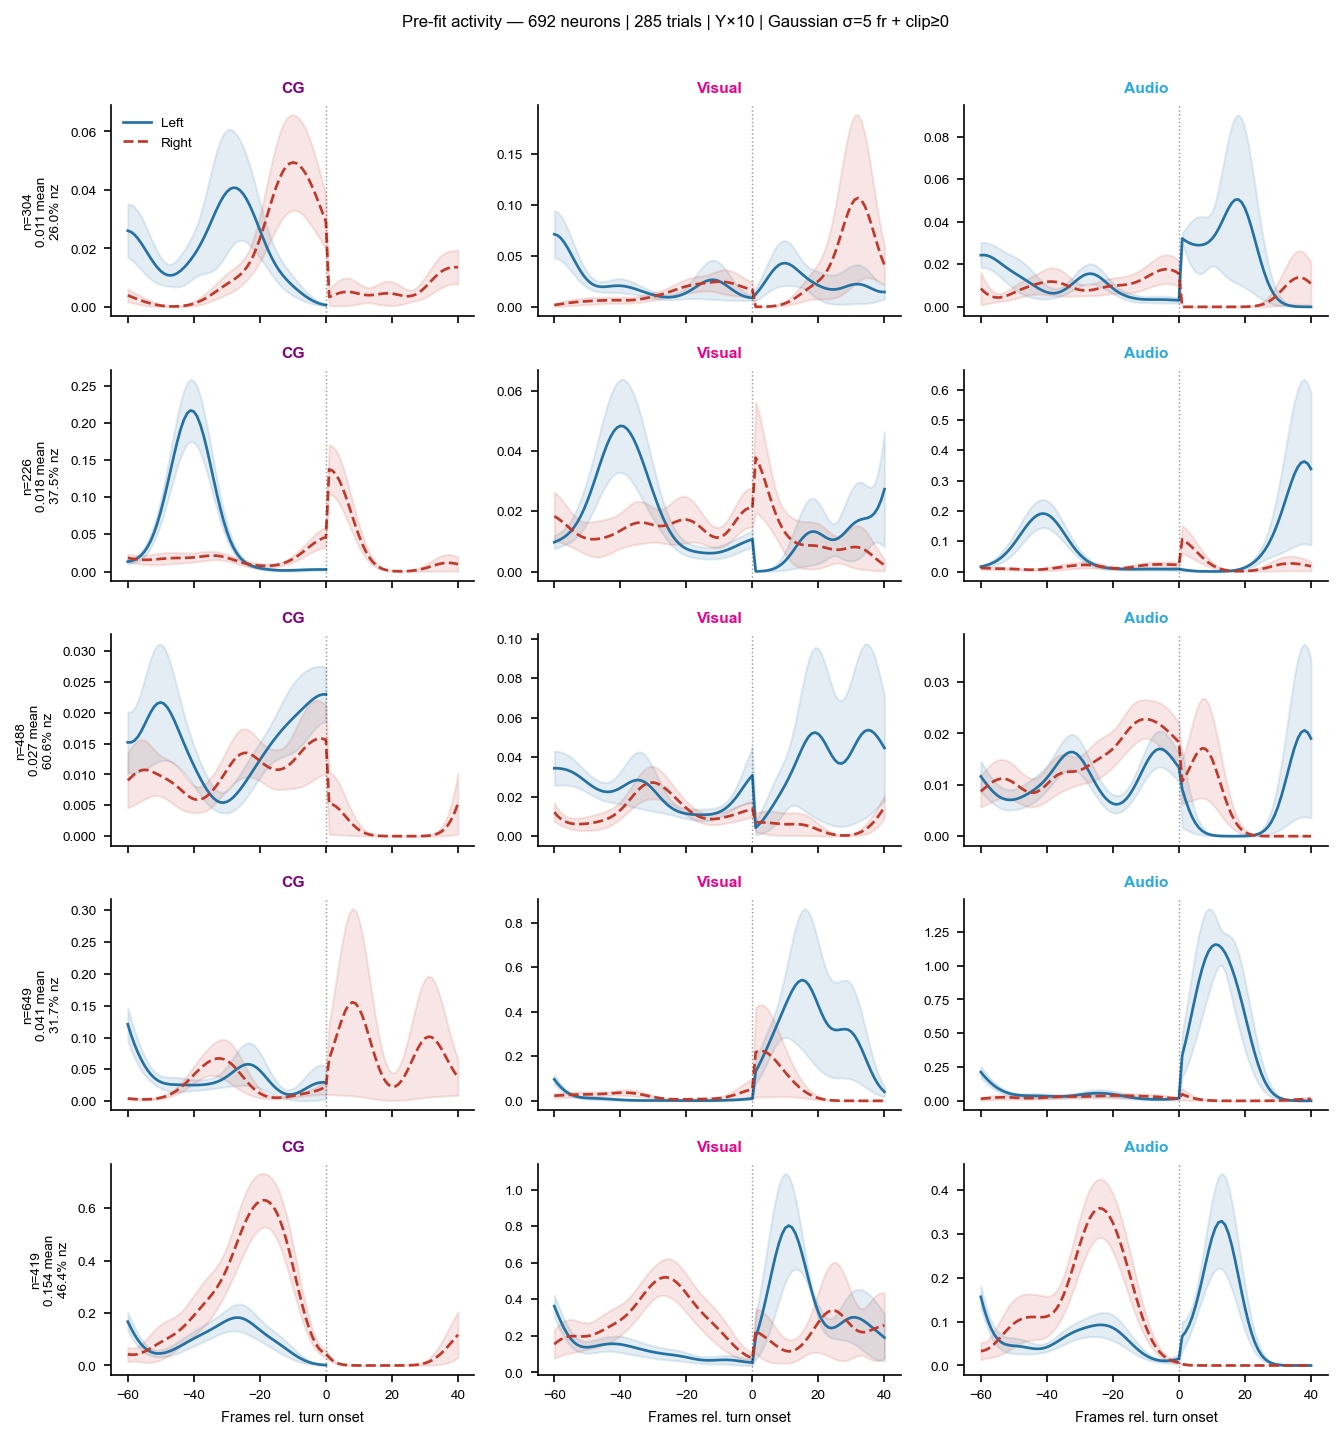

Loading: /Volumes/Akhil Data/Akhil/ProcessedData/KO-6-00/2026-03-12/glm_data_stacked.pkl
  ✓ Loaded  X: (66552, 150)  Y: (66552, 692)  [smoothed σ=5fr + clipped]
Low-activity neuron:    idx=168   mean=0.0128
Median-activity neuron: idx=201   mean=0.0221
High-activity neuron:   idx=444   mean=0.0359



In [6]:
# ── Pre-fit diagnostic: trial-averaged activity for a grid of neurons ──────
# Run AFTER open_glm_stacked_data (step 5 in run_all_sessions) but BEFORE
# fitting.  Y already has Y_SCALE and Y_SMOOTH_SIGMA applied, so this
# shows exactly what the GLM will see.
#
# Usage:
#   1. Run the two-line block at the bottom to load a specific session.
#   2. Call plot_pre_fit_neurons() — inspect the grid.
#   3. Adjust MOUSE / DATE / neuron indices as needed.

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from session_pipeline import open_glm_stacked_data, Y_SCALE, Y_SMOOTH_SIGMA

rcParams['font.family']       = 'Arial'
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top']   = False


def _one_neuron_axes(axes_row, Y, metadata, neuron_idx,
                     pre_turn=60, post_turn=40, min_trials=3):
    """
    Fill one row of axes (3 panels = CG / Visual / Audio) for a single neuron.
    Left vs Right choice split. x=0 is turn onset.
    """
    ctx_names  = {0: 'CG', 1: 'Visual', 2: 'Audio'}
    ctx_colors = {0: 'purple', 1: '#EC008C', 2: '#27AAE1'}
    frame_rel  = (metadata['frame_in_trial'].astype(int)
                  - metadata['turn_frame_in_trial'].astype(int))
    frames     = np.arange(-pre_turn, post_turn + 1)
    y_vec      = Y[:, neuron_idx]

    for col, ctx in enumerate([0, 1, 2]):
        ax       = axes_row[col]
        ctx_mask = metadata['context'] == ctx

        for choice, ls, lbl, clr in [
            (0, '-',  'Left',  '#2471A3'),
            (1, '--', 'Right', '#C0392B'),
        ]:
            cond_mask  = ctx_mask & (metadata['choice'] == choice)
            mean_tr    = np.full(len(frames), np.nan)
            sem_tr     = np.full(len(frames), np.nan)

            for i, f in enumerate(frames):
                bin_mask = cond_mask & (frame_rel == f)
                n = bin_mask.sum()
                if n >= min_trials:
                    vals       = y_vec[bin_mask]
                    mean_tr[i] = vals.mean()
                    sem_tr[i]  = vals.std() / np.sqrt(n)

            valid = ~np.isnan(mean_tr)
            ax.plot(frames[valid], mean_tr[valid],
                    color=clr, lw=1.3, ls=ls, label=lbl)
            ax.fill_between(frames[valid],
                            (mean_tr - sem_tr)[valid],
                            (mean_tr + sem_tr)[valid],
                            color=clr, alpha=0.12)

        ax.axvline(0, color='k', lw=0.7, ls=':', alpha=0.4)
        ax.set_title(ctx_names[ctx], fontsize=7.5,
                     color=ctx_colors[ctx], fontweight='bold')
        ax.tick_params(labelsize=6.5)
        sns.despine(ax=ax)


def plot_pre_fit_neurons(Y, metadata, neuron_indices=None,
                         pre_turn=60, post_turn=40, min_trials=3,
                         figsize_per_neuron=(9, 1.9)):
    """
    Plot trial-averaged activity (L vs R choice) for a list of neurons.
    Each neuron = one row of 3 panels (CG / Visual / Audio).

    Parameters
    ----------
    Y              : stacked neural data (already scaled + smoothed)
    metadata       : dict of frame-level metadata arrays
    neuron_indices : list of ints, or None → auto-select 6 representative neurons
                     (low / med-low / median / med-high / high activity + most active)
    pre_turn       : int  frames before turn to show
    post_turn      : int  frames after turn to show
    min_trials     : int  min frames per bin for a point to appear
    """
    n_neurons = Y.shape[1]
    mean_act  = Y.mean(axis=0)
    sorted_idx = np.argsort(mean_act)

    if neuron_indices is None:
        neuron_indices = [
            int(sorted_idx[n_neurons // 5]),        # low
            int(sorted_idx[2 * n_neurons // 5]),    # med-low
            int(sorted_idx[3 * n_neurons // 5]),    # med-high
            int(sorted_idx[4 * n_neurons // 5]),    # high
            int(sorted_idx[-1]),                    # most active
        ]

    n_rows  = len(neuron_indices)
    fw, fh  = figsize_per_neuron
    fig, axes = plt.subplots(
        n_rows, 3,
        figsize=(fw, fh * n_rows),
        dpi=150, sharex=True,
    )
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    smooth_str = (f'Gaussian σ={Y_SMOOTH_SIGMA} fr + clip≥0'
                  if Y_SMOOTH_SIGMA > 0 else 'no smoothing')

    for row, nidx in enumerate(neuron_indices):
        _one_neuron_axes(axes[row], Y, metadata, nidx,
                         pre_turn=pre_turn, post_turn=post_turn,
                         min_trials=min_trials)

        # Neuron label on left
        pct_nz = (Y[:, nidx] > 0).mean() * 100
        axes[row, 0].set_ylabel(
            f'n={nidx}\n{mean_act[nidx]:.3f} mean\n{pct_nz:.1f}% nz',
            fontsize=6.5, labelpad=4
        )
        if row == 0:
            axes[row, 0].legend(fontsize=6.5, frameon=False, loc='upper left')
        if row == n_rows - 1:
            for col in range(3):
                axes[row, col].set_xlabel('Frames rel. turn onset', fontsize=7)

    n_trials = len(np.unique(metadata['trial_id']))
    fig.suptitle(
        f'Pre-fit activity — {n_neurons} neurons | {n_trials} trials | '
        f'Y×{Y_SCALE} | {smooth_str}',
        fontsize=8, y=1.005
    )
    plt.tight_layout()
    plt.show()


# ── Load a session and run the diagnostic ─────────────────────────────────
MOUSE = 'KO-6-00'
DATE  = '2026-03-12'

X_diag, Y_diag, meta_diag, *_ = open_glm_stacked_data(
    MOUSE, DATE, print_summary=False
)

# Auto-select representative neurons (or pass a specific list):
#   plot_pre_fit_neurons(Y_diag, meta_diag, neuron_indices=[42, 68, 201, 350])
plot_pre_fit_neurons(Y_diag, meta_diag)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top']   = False


def plot_raw_trial_avg(
    Y, metadata,
    neuron_idx  = 0,
    pre_turn    = 125,
    post_turn   = 75,
    min_trials  = 3,
    smooth_sigmas = [0, 2, 5],   # 0 = no smoothing, then try σ=2 and σ=5
):
    """
    Plot trial-averaged raw neural activity for one neuron,
    showing the effect of different Gaussian smoothing levels.

    Each column = one smoothing level.
    Each row    = one context (CG / Visual / Audio).
    Each panel  = Left vs Right choice split (solid vs dashed).

    This is a pre-fit diagnostic — no model predictions, just raw data.
    """
    ctx_names  = {0: 'CG', 1: 'Visual', 2: 'Audio'}
    ctx_colors = {0: 'purple', 1: '#EC008C', 2: '#27AAE1'}

    frame_rel = (metadata['frame_in_trial'].astype(int)
                 - metadata['turn_frame_in_trial'].astype(int))
    frames    = np.arange(-pre_turn, post_turn + 1)
    y_raw     = Y[:, neuron_idx]

    n_smooth = len(smooth_sigmas)
    n_ctx    = 3
    fig, axes = plt.subplots(
        n_ctx, n_smooth,
        figsize=(4 * n_smooth, 2.5 * n_ctx),
        dpi=150, sharex=True, sharey=True
    )
    if n_ctx == 1: axes = axes[np.newaxis, :]
    if n_smooth == 1: axes = axes[:, np.newaxis]

    for col, sigma in enumerate(smooth_sigmas):
        for row, ctx in enumerate([0, 1, 2]):
            ax  = axes[row, col]
            ctx_mask = metadata['context'] == ctx

            for choice, ls, lbl, clr in [
                (0, '-',  'Left',  '#2471A3'),
                (1, '--', 'Right', '#C0392B'),
            ]:
                cond_mask = ctx_mask & (metadata['choice'] == choice)
                mean_trace = np.full(len(frames), np.nan)
                sem_trace  = np.full(len(frames), np.nan)

                for i, f in enumerate(frames):
                    bin_mask = cond_mask & (frame_rel == f)
                    n = bin_mask.sum()
                    if n >= min_trials:
                        vals = y_raw[bin_mask]
                        mean_trace[i] = vals.mean()
                        sem_trace[i]  = vals.std() / np.sqrt(n)

                # Apply smoothing to mean only
                if sigma > 0:
                    valid = ~np.isnan(mean_trace)
                    mean_trace[valid] = gaussian_filter1d(
                        mean_trace[valid], sigma=sigma
                    )

                valid = ~np.isnan(mean_trace)
                ax.plot(frames[valid], mean_trace[valid],
                        color=clr, lw=1.4, ls=ls, label=lbl)
                ax.fill_between(
                    frames[valid],
                    (mean_trace - sem_trace)[valid],
                    (mean_trace + sem_trace)[valid],
                    color=clr, alpha=0.12
                )

            ax.axvline(0, color='k', lw=0.7, ls=':', alpha=0.5)

            # Labels
            if row == 0:
                title = f'No smoothing' if sigma == 0 else f'Gaussian σ={sigma} frames'
                ax.set_title(title, fontsize=8)
            if col == 0:
                ax.set_ylabel(ctx_names[ctx], fontsize=8,
                              color=ctx_colors[ctx], fontweight='bold')
            if row == n_ctx - 1:
                ax.set_xlabel('Frames rel. turn onset', fontsize=7.5)
            if row == 0 and col == 0:
                ax.legend(fontsize=7, frameon=False)

            ax.tick_params(labelsize=7)

    # Summary stats
    n_trials_total = len(np.unique(metadata['trial_id']))
    event_rate     = y_raw.mean()
    pct_nonzero    = (y_raw > 0).mean() * 100

    fig.suptitle(
        f'Neuron {neuron_idx}  |  {n_trials_total} trials  |  '
        f'mean activity = {event_rate:.3f}  |  '
        f'{pct_nonzero:.1f}% frames non-zero\n'
        f'(Y already scaled ×{Y_SCALE})',
        fontsize=8, y=1.02
    )
    plt.tight_layout()
    plt.show()


# ── Pick a neuron to inspect ───────────────────────────────────────────────
# Try a few: median-activity neuron, a high-activity one, a low-activity one
from session_pipeline import open_glm_stacked_data, Y_SCALE

MOUSE = 'KO-6-00'
DATE  = '2026-03-12'

X_diag, Y_diag, meta_diag, *_ = open_glm_stacked_data(MOUSE, DATE, print_summary=False)

# Rank neurons by mean activity and inspect representative ones
mean_activity  = Y_diag.mean(axis=0)
sorted_idx     = np.argsort(mean_activity)
n              = Y_diag.shape[1]

neuron_low    = int(sorted_idx[n // 4])       # 25th percentile activity
neuron_median = int(sorted_idx[n // 2])       # median activity
neuron_high   = int(sorted_idx[3 * n // 4])   # 75th percentile activity

print(f'Low-activity neuron:    idx={neuron_low:<4d}  mean={mean_activity[neuron_low]:.4f}')
print(f'Median-activity neuron: idx={neuron_median:<4d}  mean={mean_activity[neuron_median]:.4f}')
print(f'High-activity neuron:   idx={neuron_high:<4d}  mean={mean_activity[neuron_high]:.4f}')
print()

# # Plot — change neuron_idx to any of the above (or any specific index)
# plot_raw_trial_avg(Y_diag, meta_diag, neuron_idx=neuron_median,
#                    smooth_sigmas=[0, 2, 5])

In [7]:
Y_diag.shape

(66552, 692)

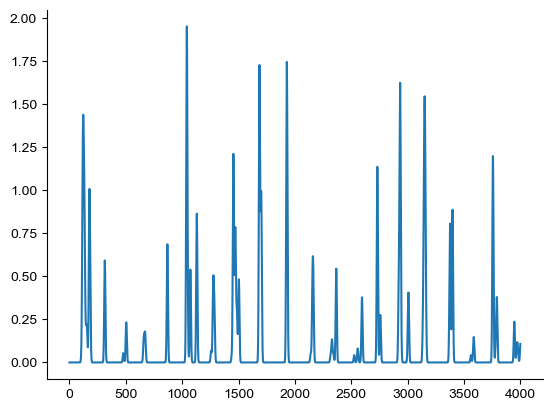

In [8]:
plt.plot(Y_diag[0:4000,419])